### Data Pre-processing & Transformation

In [1]:
%pip install Sastrawi

import json
import re
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction import text as sklearn_text

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

DATA_PATH = Path("dataset\ICAR_Text_Extracted.json")
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_K_FEATURES = 1000

# Untuk mempercepat: set False dulu. Ubah ke True kalau butuh stemming.
USE_STEMMING = False

<>:19: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:19: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\labit\AppData\Local\Temp\ipykernel_7268\4090108420.py:19: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  DATA_PATH = Path("dataset\ICAR_Text_Extracted.json")


Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2) Load dataset JSON
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for category, files in data.items():
    if isinstance(files, dict):
        for fname, txt in files.items():
            rows.append({
                "category": category,
                "doc_id": fname,
                "text_raw": str(txt) if txt is not None else ""
            })

df = pd.DataFrame(rows)
print("Jumlah dokumen:", len(df))
df.head()

Jumlah dokumen: 159


,category,doc_id,text_raw
0,Annual Reports,anrep-02003.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
1,Annual Reports,AR-2019-20.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,\n--- Page 1 ---\nWeb Url -https://icar.gov.in...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,\n--- Page 1 ---\nANNUAL REPORT 2018-19 or 04[...


In [3]:
# 3) Data cleaning + normalization + stopword removal
stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")


def basic_cleaning(text: str) -> str:
    text = text.lower()                                  # lowercase
    text = url_pattern.sub(" ", text)                    # hapus URL
    text = digit_pattern.sub(" ", text)                  # hapus angka
    text = non_alpha_pattern.sub(" ", text)              # hapus tanda baca/simbol
    text = space_pattern.sub(" ", text).strip()          # rapikan spasi
    return text


@lru_cache(maxsize=100_000)
def stem_token(token: str) -> str:
    return STEMMER_ID.stem(token)


def normalize_text(text: str) -> str:
    if not USE_STEMMING or STEMMER_ID is None:
        return text
    tokens = text.split()
    return " ".join(stem_token(t) for t in tokens)


def remove_stopwords(text: str) -> str:
    tokens = [t for t in text.split() if t not in stopwords_all and len(t) > 2]
    return " ".join(tokens)


def preprocess_pipeline(text: str) -> str:
    text = basic_cleaning(text)
    text = normalize_text(text)
    text = remove_stopwords(text)
    return text

In [4]:
# 4) Terapkan preprocessing ke kolom text_clean
df["text_clean"] = df["text_raw"].apply(preprocess_pipeline)

print("Contoh hasil preprocessing:")
df[["category", "doc_id", "text_clean"]].head()

Contoh hasil preprocessing:


,category,doc_id,text_clean
0,Annual Reports,anrep-02003.pdf,page web url dare icar annual report departmen...
1,Annual Reports,AR-2019-20.pdf,page web url page indian council agricultvral ...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,page web url page indian council agricultural ...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,page web url page indian council agricultural ...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,page annual report taaa department agricultura...


## 4.1 Visualisasi Before vs After Preprocessing
Menampilkan perbandingan teks sebelum (`text_raw`) dan sesudah preprocessing (`text_clean`) secara kuantitatif (panjang karakter & token) dan kualitatif (contoh teks).

Contoh before vs after (5 dokumen):


,category,doc_id,text_raw,text_clean
0,Annual Reports,anrep-02003.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url dare icar annual report departmen...
1,Annual Reports,AR-2019-20.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url page indian council agricultvral ...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,\n--- Page 1 ---\nWeb Url -https://icar.gov.in...,page web url page indian council agricultural ...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url page indian council agricultural ...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,\n--- Page 1 ---\nANNUAL REPORT 2018-19 or 04[...,page annual report taaa department agricultura...


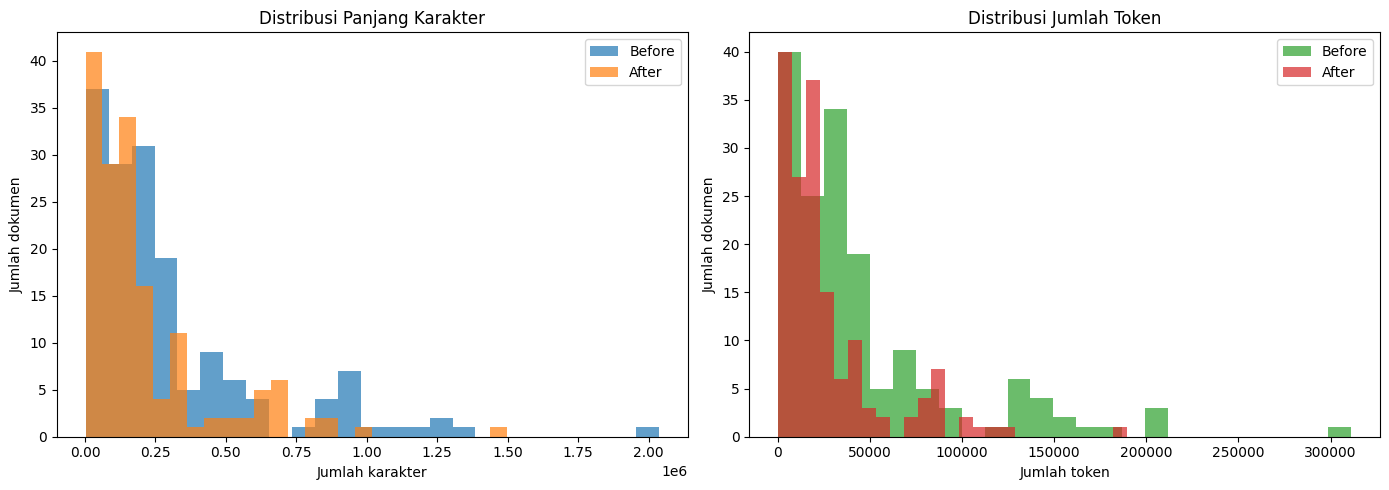

Rata-rata panjang karakter before: 301506.55
Rata-rata panjang karakter after : 213158.64
Pengurangan rata-rata karakter   : 29.30%

Rata-rata token before: 45498.33
Rata-rata token after : 26632.14
Pengurangan rata-rata token   : 41.47%


In [5]:
import matplotlib.pyplot as plt

# Data ringkas before vs after
viz_df = df[["category", "doc_id", "text_raw", "text_clean"]].copy()
viz_df["len_raw"] = viz_df["text_raw"].str.len()
viz_df["len_clean"] = viz_df["text_clean"].str.len()
viz_df["tok_raw"] = viz_df["text_raw"].str.split().str.len()
viz_df["tok_clean"] = viz_df["text_clean"].str.split().str.len()

# 1) Contoh teks sebelum vs sesudah (dipotong agar rapi)
preview = viz_df[["category", "doc_id", "text_raw", "text_clean"]].head(5).copy()
preview["text_raw"] = preview["text_raw"].str.slice(0, 220) + "..."
preview["text_clean"] = preview["text_clean"].str.slice(0, 220) + "..."
print("Contoh before vs after (5 dokumen):")
display(preview)

# 2) Histogram panjang karakter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(viz_df["len_raw"], bins=25, alpha=0.7, color="#1f77b4", label="Before")
axes[0].hist(viz_df["len_clean"], bins=25, alpha=0.7, color="#ff7f0e", label="After")
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah karakter")
axes[0].set_ylabel("Jumlah dokumen")
axes[0].legend()

# 3) Histogram jumlah token
axes[1].hist(viz_df["tok_raw"], bins=25, alpha=0.7, color="#2ca02c", label="Before")
axes[1].hist(viz_df["tok_clean"], bins=25, alpha=0.7, color="#d62728", label="After")
axes[1].set_title("Distribusi Jumlah Token")
axes[1].set_xlabel("Jumlah token")
axes[1].set_ylabel("Jumlah dokumen")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4) Rata-rata pengurangan
char_reduction_pct = (1 - (viz_df["len_clean"].mean() / viz_df["len_raw"].mean())) * 100
tok_reduction_pct = (1 - (viz_df["tok_clean"].mean() / viz_df["tok_raw"].mean())) * 100

print(f"Rata-rata panjang karakter before: {viz_df['len_raw'].mean():.2f}")
print(f"Rata-rata panjang karakter after : {viz_df['len_clean'].mean():.2f}")
print(f"Pengurangan rata-rata karakter   : {char_reduction_pct:.2f}%")
print()
print(f"Rata-rata token before: {viz_df['tok_raw'].mean():.2f}")
print(f"Rata-rata token after : {viz_df['tok_clean'].mean():.2f}")
print(f"Pengurangan rata-rata token   : {tok_reduction_pct:.2f}%")

In [6]:
# 5) Data transformation: TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(df["text_clean"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("Shape TF-IDF:", X.shape)
print("Jumlah fitur:", len(feature_names))

Shape TF-IDF: (159, 478980)
Jumlah fitur: 478980


## 5.1 Bag of Words + Visualisasi N-gram
Bagian ini membuat representasi **Bag of Words (BoW)** dan menampilkan n-gram teratas (unigram & bigram) berdasarkan frekuensi kemunculan kata.

Tabel Before vs After - Bag of Words:


,Komponen,Before,After,Selisih (After-Before),Reduksi (%)
0,Jumlah Fitur BoW,5.727170e+05,4.789800e+05,-9.373700e+04,16.367071
1,Jumlah token non-zero (nnz),3.137878e+06,2.055142e+06,-1.082736e+06,34.505357
2,Kerapatan matriks (%),3.445870e+00,2.698530e+00,-7.473392e-01,21.687971


Tabel Before vs After - N-gram:


,Komponen,Before,After,Selisih (After-Before),Reduksi (%)
0,Unigram,58848,47353,-11495,19.533374
1,Bigram,513869,431627,-82242,16.004468


Tabel Per-feature (Top 20) - Unigram:


,feature,n,count_before,count_after,selisih,perubahan_%
554464,prac,1,0,244,244,100.000000
485406,nicgw,1,45,181,136,302.222222
165180,cas,1,111,242,131,118.018018
469620,mon,1,107,195,88,82.242991
582292,qdty,1,0,80,80,100.000000
181348,cnrb,1,0,66,66,100.000000
386270,ingr,1,163,229,66,40.490798
315462,fsw,1,0,62,62,100.000000
474144,mtu,1,188,244,56,29.787234
646593,singh,1,4023,4076,53,1.317425


Tabel Per-feature (Top 20) - Bigram:


,feature,n,count_before,count_after,selisih,perubahan_%
453424,maturity days,2,28,2851,2823,10082.142857
524057,page icar,2,54,2364,2310,4277.777778
716160,title itk,2,0,2065,2065,100.000000
76197,advisory farmers,2,0,1667,1667,100.000000
784657,yield maturity,2,10,1575,1565,15650.000000
329179,government india,2,0,1118,1118,100.000000
602200,report page,2,0,1092,1092,100.000000
678841,suitable irrigated,2,6,1079,1073,17883.333333
652360,soil deficient,2,0,1043,1043,100.000000
744266,used itk,2,0,966,966,100.000000


File per-feature tersimpan: output\icar_bow_ngram_per_feature_compare.csv


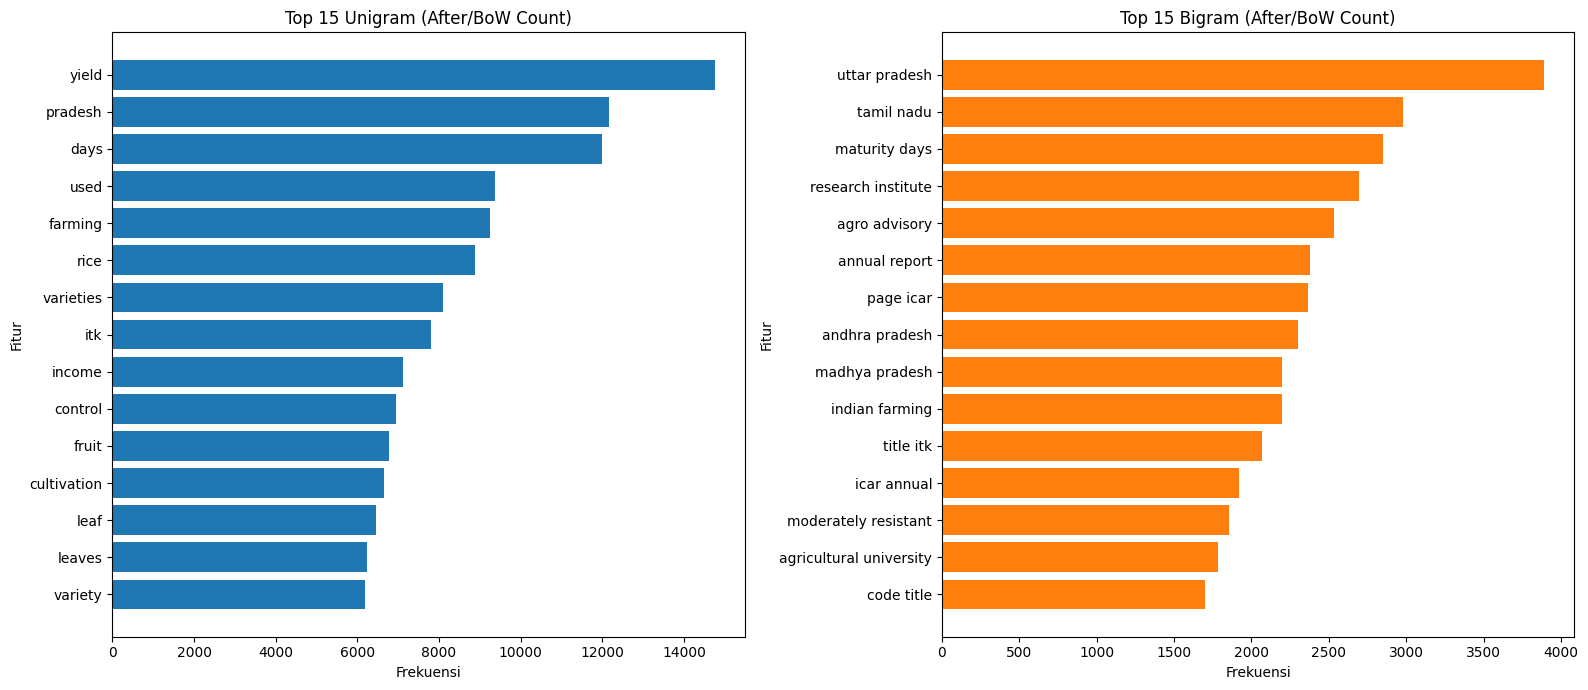

In [7]:
# 5.1) Bag of Words (BoW) + N-gram: Before vs After (tabel terpisah + per-feature)
# Before = text_raw, After = text_clean

# === BoW BEFORE (teks mentah) ===
bow_vectorizer_before = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow_before = bow_vectorizer_before.fit_transform(df["text_raw"].fillna(""))
bow_features_before = np.array(bow_vectorizer_before.get_feature_names_out())

term_counts_before = np.asarray(X_bow_before.sum(axis=0)).ravel()
ngram_before_df = pd.DataFrame({
    "feature": bow_features_before,
    "count_before": term_counts_before
})
ngram_before_df["n"] = ngram_before_df["feature"].str.split().str.len()

# === BoW AFTER (teks hasil preprocessing) ===
bow_vectorizer_after = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow = bow_vectorizer_after.fit_transform(df["text_clean"].fillna(""))
bow_feature_names = np.array(bow_vectorizer_after.get_feature_names_out())

term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
ngram_df = pd.DataFrame({
    "feature": bow_feature_names,
    "count_after": term_counts
})
ngram_df["n"] = ngram_df["feature"].str.split().str.len()

# === TABEL 1: Ringkasan Bag of Words ===
bow_compare_df = pd.DataFrame([
    {"Komponen": "Jumlah Fitur BoW", "Before": len(bow_features_before), "After": len(bow_feature_names)},
    {"Komponen": "Jumlah token non-zero (nnz)", "Before": int(X_bow_before.nnz), "After": int(X_bow.nnz)},
    {
        "Komponen": "Kerapatan matriks (%)",
        "Before": (X_bow_before.nnz / (X_bow_before.shape[0] * X_bow_before.shape[1])) * 100,
        "After": (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100
    }
])
bow_compare_df["Selisih (After-Before)"] = bow_compare_df["After"] - bow_compare_df["Before"]
bow_compare_df["Reduksi (%)"] = np.where(
    bow_compare_df["Before"] > 0,
    (1 - (bow_compare_df["After"] / bow_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - Bag of Words:")
display(bow_compare_df)

# === TABEL 2: Ringkasan N-gram ===
ngram_compare_df = pd.DataFrame([
    {"Komponen": "Unigram", "Before": int((ngram_before_df["n"] == 1).sum()), "After": int((ngram_df["n"] == 1).sum())},
    {"Komponen": "Bigram", "Before": int((ngram_before_df["n"] == 2).sum()), "After": int((ngram_df["n"] == 2).sum())}
])
ngram_compare_df["Selisih (After-Before)"] = ngram_compare_df["After"] - ngram_compare_df["Before"]
ngram_compare_df["Reduksi (%)"] = np.where(
    ngram_compare_df["Before"] > 0,
    (1 - (ngram_compare_df["After"] / ngram_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - N-gram:")
display(ngram_compare_df)

# === TABEL 3: Per-feature Before vs After ===
feature_compare_df = pd.merge(
    ngram_before_df[["feature", "n", "count_before"]],
    ngram_df[["feature", "n", "count_after"]],
    on="feature",
    how="outer",
    suffixes=("_before", "_after")
)

feature_compare_df["n"] = feature_compare_df["n_before"].fillna(feature_compare_df["n_after"]).astype(int)
feature_compare_df["count_before"] = feature_compare_df["count_before"].fillna(0).astype(int)
feature_compare_df["count_after"] = feature_compare_df["count_after"].fillna(0).astype(int)
feature_compare_df = feature_compare_df[["feature", "n", "count_before", "count_after"]]
feature_compare_df["selisih"] = feature_compare_df["count_after"] - feature_compare_df["count_before"]
feature_compare_df["perubahan_%"] = np.where(
    feature_compare_df["count_before"] > 0,
    ((feature_compare_df["count_after"] - feature_compare_df["count_before"]) / feature_compare_df["count_before"]) * 100,
    np.where(feature_compare_df["count_after"] > 0, 100.0, 0.0)
)

TOP_FEATURE_COMPARE = 20
per_feature_unigram = (
    feature_compare_df[feature_compare_df["n"] == 1]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)
per_feature_bigram = (
    feature_compare_df[feature_compare_df["n"] == 2]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Unigram:")
display(per_feature_unigram)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Bigram:")
display(per_feature_bigram)

# Simpan tabel lengkap per-feature agar bisa dicek semua fitur
per_feature_path = OUT_DIR / "icar_bow_ngram_per_feature_compare.csv"
feature_compare_df.sort_values(["n", "selisih"], ascending=[True, False]).to_csv(per_feature_path, index=False)
print("File per-feature tersimpan:", per_feature_path)

# === Top n-gram AFTER (opsional visualisasi) ===
TOP_SHOW = 15
unigram_top = feature_compare_df[feature_compare_df["n"] == 1].sort_values("count_after", ascending=False).head(TOP_SHOW)
bigram_top = feature_compare_df[feature_compare_df["n"] == 2].sort_values("count_after", ascending=False).head(TOP_SHOW)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(unigram_top["feature"][::-1], unigram_top["count_after"][::-1], color="#1f77b4")
axes[0].set_title(f"Top {len(unigram_top)} Unigram (After/BoW Count)")
axes[0].set_xlabel("Frekuensi")
axes[0].set_ylabel("Fitur")

axes[1].barh(bigram_top["feature"][::-1], bigram_top["count_after"][::-1], color="#ff7f0e")
axes[1].set_title(f"Top {len(bigram_top)} Bigram (After/BoW Count)")
axes[1].set_xlabel("Frekuensi")
axes[1].set_ylabel("Fitur")

plt.tight_layout()
plt.show()

In [8]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)

print("Top 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

Ringkasan jumlah fitur before vs after:


,Tahap,Jumlah Fitur
0,Before (semua fitur),478980
1,After (top-k terpilih),1000


Top 20 BEFORE (sebelum feature selection):


,feature,mean_tfidf
475324,yield,0.045361
147843,farming,0.036702
322843,pradesh,0.030826
98760,days,0.030401
163506,fruit,0.030219
367806,rice,0.029290
455768,varieties,0.028661
93461,cultivation,0.025492
456661,variety,0.023897
450923,used,0.023844


Top 20 AFTER (sesudah feature selection):


,feature,mean_tfidf
0,yield,0.045361
1,farming,0.036702
2,pradesh,0.030826
3,days,0.030401
4,fruit,0.030219
5,rice,0.029290
6,varieties,0.028661
7,cultivation,0.025492
8,variety,0.023897
9,used,0.023844


In [9]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
removed_count = len(feature_names) - len(selected_features)
reduction_pct = (removed_count / len(feature_names)) * 100 if len(feature_names) > 0 else 0

compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)},
    {"Tahap": "Fitur terbuang", "Jumlah Fitur": removed_count}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)
print(f"Persentase reduksi fitur: {reduction_pct:.2f}%")

print("\nCatatan: Top-20 BEFORE dan AFTER bisa sama karena feature selection mengambil fitur dengan mean_tfidf tertinggi.")
print("Yang berubah adalah jumlah total fitur (dimensi), bukan ranking 20 teratas.")

print("\nTop 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

# Tampilkan contoh fitur yang DIBUANG agar perbedaan lebih terlihat
if removed_count > 0:
    removed_features_df = before_features_df.iloc[top_k:].copy()
    print("Contoh 20 fitur yang dibuang (bukan top-k):")
    display(removed_features_df.head(20))
else:
    print("Tidak ada fitur yang dibuang (top_k >= jumlah fitur awal).")

Ringkasan jumlah fitur before vs after:


,Tahap,Jumlah Fitur
0,Before (semua fitur),478980
1,After (top-k terpilih),1000
2,Fitur terbuang,477980


Persentase reduksi fitur: 99.79%

Catatan: Top-20 BEFORE dan AFTER bisa sama karena feature selection mengambil fitur dengan mean_tfidf tertinggi.
Yang berubah adalah jumlah total fitur (dimensi), bukan ranking 20 teratas.

Top 20 BEFORE (sebelum feature selection):


,feature,mean_tfidf
475324,yield,0.045361
147843,farming,0.036702
322843,pradesh,0.030826
98760,days,0.030401
163506,fruit,0.030219
367806,rice,0.029290
455768,varieties,0.028661
93461,cultivation,0.025492
456661,variety,0.023897
450923,used,0.023844


Top 20 AFTER (sesudah feature selection):


,feature,mean_tfidf
0,yield,0.045361
1,farming,0.036702
2,pradesh,0.030826
3,days,0.030401
4,fruit,0.030219
5,rice,0.029290
6,varieties,0.028661
7,cultivation,0.025492
8,variety,0.023897
9,used,0.023844


Contoh 20 fitur yang dibuang (bukan top-k):


,feature,mean_tfidf
265575,mid,0.003772
318696,possible,0.003771
427250,technological,0.003767
294750,organic farming,0.003764
472753,write,0.003764
470290,winter,0.003763
324023,prcia,0.003762
214306,insects,0.003762
412312,strategic,0.003757
88733,critical,0.003755


## 6.1 Visualisasi Before vs After: Transformation & Feature Selection
Visualisasi ini membandingkan kondisi **sebelum** (TF-IDF penuh) dan **sesudah** (TF-IDF tereduksi/top-k) pada proses transformasi dan seleksi fitur.

Ringkasan Before vs After:


,Tahap,Jumlah Dokumen,Jumlah Fitur,Rata-rata fitur non-zero/dokumen,Kerapatan Matriks (%)
0,Before (TF-IDF penuh),159,478980,12925.421384,2.698530
1,After (TF-IDF tereduksi),159,1000,575.886792,57.588679


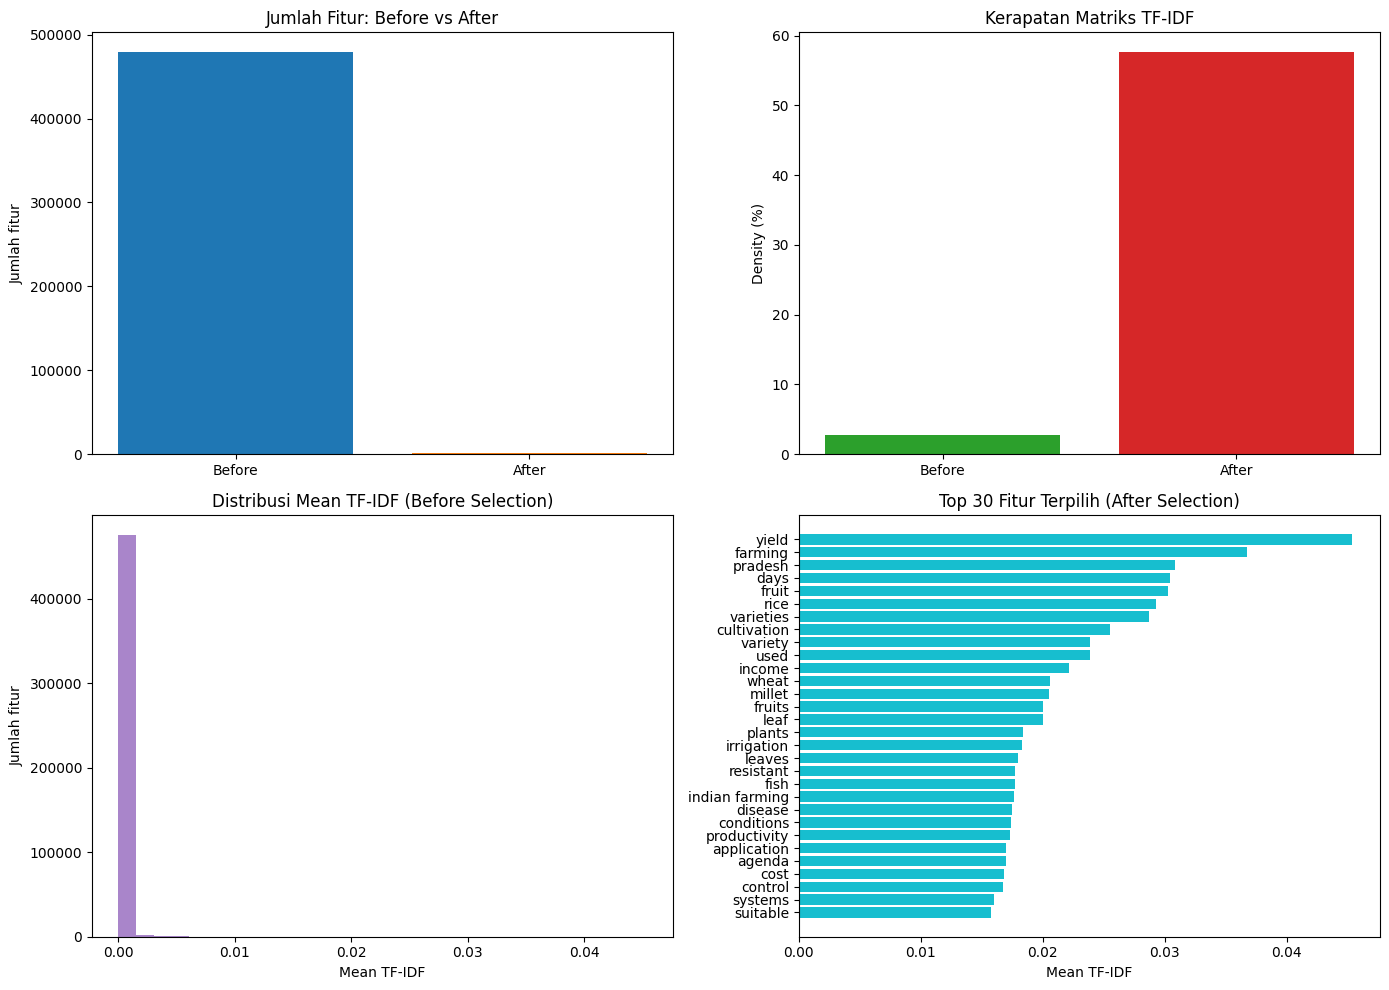

Reduksi jumlah fitur: 99.79%


In [10]:
# Ringkasan metrik before vs after
before_features = X.shape[1]
after_features = X_selected.shape[1]

before_density = X.nnz / (X.shape[0] * X.shape[1])
after_density = X_selected.nnz / (X_selected.shape[0] * X_selected.shape[1])

before_nnz_doc = np.asarray((X != 0).sum(axis=1)).ravel()
after_nnz_doc = np.asarray((X_selected != 0).sum(axis=1)).ravel()

summary_df = pd.DataFrame([
    {
        "Tahap": "Before (TF-IDF penuh)",
        "Jumlah Dokumen": X.shape[0],
        "Jumlah Fitur": before_features,
        "Rata-rata fitur non-zero/dokumen": before_nnz_doc.mean(),
        "Kerapatan Matriks (%)": before_density * 100
    },
    {
        "Tahap": "After (TF-IDF tereduksi)",
        "Jumlah Dokumen": X_selected.shape[0],
        "Jumlah Fitur": after_features,
        "Rata-rata fitur non-zero/dokumen": after_nnz_doc.mean(),
        "Kerapatan Matriks (%)": after_density * 100
    }
])

print("Ringkasan Before vs After:")
display(summary_df)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Jumlah fitur before vs after
axes[0, 0].bar(["Before", "After"], [before_features, after_features], color=["#1f77b4", "#ff7f0e"])
axes[0, 0].set_title("Jumlah Fitur: Before vs After")
axes[0, 0].set_ylabel("Jumlah fitur")

# 2) Kerapatan matriks before vs after
axes[0, 1].bar(["Before", "After"], [before_density * 100, after_density * 100], color=["#2ca02c", "#d62728"])
axes[0, 1].set_title("Kerapatan Matriks TF-IDF")
axes[0, 1].set_ylabel("Density (%)")

# 3) Distribusi skor mean TF-IDF (semua fitur = before selection)
axes[1, 0].hist(mean_scores, bins=30, color="#9467bd", alpha=0.8)
axes[1, 0].set_title("Distribusi Mean TF-IDF (Before Selection)")
axes[1, 0].set_xlabel("Mean TF-IDF")
axes[1, 0].set_ylabel("Jumlah fitur")

# 4) Top-k mean TF-IDF (after selection)
top_plot_k = min(30, len(selected_features))
top_names = selected_features[:top_plot_k]
top_vals = mean_scores[top_idx][:top_plot_k]

axes[1, 1].barh(top_names[::-1], top_vals[::-1], color="#17becf")
axes[1, 1].set_title(f"Top {top_plot_k} Fitur Terpilih (After Selection)")
axes[1, 1].set_xlabel("Mean TF-IDF")

plt.tight_layout()
plt.show()

# Persentase reduksi dimensi
reduction_pct = (1 - (after_features / before_features)) * 100
print(f"Reduksi jumlah fitur: {reduction_pct:.2f}%")

In [11]:
# 7) Simpan hasil
preprocessed_path = OUT_DIR / "icar_preprocessed.csv"
features_path = OUT_DIR / "icar_selected_features.csv"
tfidf_selected_path = OUT_DIR / "icar_tfidf_selected.csv"

# a) Teks hasil preprocessing
df[["category", "doc_id", "text_clean"]].to_csv(preprocessed_path, index=False)

# b) Fitur terpilih
selected_df.to_csv(features_path, index=False)

# c) Matriks TF-IDF tereduksi
tfidf_df = pd.DataFrame(X_selected.toarray(), columns=selected_features)
tfidf_df.insert(0, "doc_id", df["doc_id"].values)
tfidf_df.to_csv(tfidf_selected_path, index=False)

print("Selesai disimpan:")
print("-", preprocessed_path)
print("-", features_path)
print("-", tfidf_selected_path)

Selesai disimpan:
- output\icar_preprocessed.csv
- output\icar_selected_features.csv
- output\icar_tfidf_selected.csv


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np
from IPython.display import display

df_prep = pd.read_csv("output/icar_preprocessed.csv")
texts = df_prep["text_clean"].fillna("")
doc_ids = df_prep["doc_id"]

def show_ngram_and_matrix(texts, doc_ids, ngram_range, title, top_n=15):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")
    
    # 1. Feature Frequency Table
    vec_full = CountVectorizer(ngram_range=ngram_range)
    X_full = vec_full.fit_transform(texts)
    sum_words = X_full.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec_full.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    df_freq = pd.DataFrame(words_freq[:top_n], columns=["Feature", "Frekuensi"])
    print("\n1. Tabel Frekuensi Fitur (Top 15):")
    display(df_freq)
    
    # 2. Document-Term Matrix (using top N features)
    top_features = [w[0] for w in words_freq[:top_n]]
    # Sort alphabetically to match standard Vectorizer behavior
    top_features.sort()
    
    vec_matrix = CountVectorizer(ngram_range=ngram_range, vocabulary=top_features)
    X_matrix = vec_matrix.fit_transform(texts)
    
    df_matrix = pd.DataFrame(X_matrix.toarray(), columns=vec_matrix.get_feature_names_out())
    df_matrix.insert(0, "doc_id", doc_ids)
    
    print("\n2. Document-Term Matrix (Top 15 Fitur):")
    display(df_matrix.head(100))
    
    return top_features

# --- Eksekusi N-Gram ---
top_unigrams = show_ngram_and_matrix(texts, doc_ids, (1,1), "N-gram: ngram_range=(1,1) | Unigram | BoW (Bag of Words)")
show_ngram_and_matrix(texts, doc_ids, (2,2), "N-gram: ngram_range=(2,2) | Bigram")
top_uni_bi = show_ngram_and_matrix(texts, doc_ids, (1,2), "N-gram: ngram_range=(1,2) | Unigram + Bigram")



N-gram: ngram_range=(1,1) | Unigram | BoW (Bag of Words)

1. Tabel Frekuensi Fitur (Top 15):


,Feature,Frekuensi
0,icar,27528
1,page,19754
2,farmers,19594
3,agricultural,19566
4,research,18816
5,water,17500
6,crop,15848
7,yield,14749
8,production,14734
9,management,14436



2. Document-Term Matrix (Top 15 Fitur):


,doc_id,agricultural,agriculture,crop,crops,farmers,icar,india,management,page,production,research,seed,soil,water,yield
0,anrep-02003.pdf,422,247,304,179,206,451,175,320,287,353,503,205,230,243,470
1,AR-2019-20.pdf,507,322,257,200,278,708,206,301,218,267,514,229,137,200,735
2,DARE-Annual-Report-2017-18.pdf,526,289,236,204,328,659,232,280,210,303,466,161,170,159,363
3,DARE-ICAR-Annual-Report 2016-17.pdf,420,272,209,188,269,606,213,297,225,229,447,132,156,188,228
4,DARE-ICAR-AR-2018-19.pdf,500,281,256,164,306,656,201,310,232,242,497,174,186,211,538
5,ICAR Eng AR_2023-24 for web.pdf,414,363,295,245,394,901,224,372,263,238,369,453,263,179,1020
6,icar-2001.pdf,452,246,290,168,163,413,181,321,283,340,517,288,205,282,526
7,ICAR-Annual-Report-2022-23-English.pdf,380,308,327,251,328,868,230,320,275,224,366,340,205,245,1418
8,ICAR-AR-2020.pdf,529,287,242,179,289,906,237,328,244,246,473,283,173,156,638
9,ICAR-AR-21-22ÔÇôE.pdf,492,289,232,223,254,664,216,318,241,277,409,504,143,165,788



N-gram: ngram_range=(2,2) | Bigram

1. Tabel Frekuensi Fitur (Top 15):


...

,doc_id,agricultural research,agro advisory,andhra pradesh,annual report,council agricultural,indian council,indian farming,madhya pradesh,maturity days,new delhi,page icar,research institute,tamil nadu,title itk,uttar pradesh
0,anrep-02003.pdf,134,0,69,130,25,24,6,56,7,118,1,86,52,0,120
1,AR-2019-20.pdf,119,1,86,207,34,34,1,109,285,103,0,119,108,0,141
2,DARE-Annual-Report-2017-18.pdf,114,0,77,200,27,30,2,70,28,143,1,65,90,0,118
3,DARE-ICAR-Annual-Report 2016-17.pdf,95,0,100,214,26,29,3,131,3,115,2,60,117,0,145
4,DARE-ICAR-AR-2018-19.pdf,143,0,32,222,26,30,1,49,180,171,0,111,67,0,83
5,ICAR Eng AR_2023-24 for web.pdf,84,3,102,256,31,33,12,133,496,85,0,48,125,0,216
6,icar-2001.pdf,123,0,87,124,22,26,3,99,1,135,1,79,73,0,148
7,ICAR-Annual-Report-2022-23-English.pdf,67,3,151,267,29,31,4,199,790,113,0,63,199,0,207
8,ICAR-AR-2020.pdf,111,1,95,232,27,30,3,68,267,108,0,80,90,0,121
9,ICAR-AR-21-22ÔÇôE.pdf,88,1,115,227,27,33,4,147,361,94,2,84,124,0,155



N-gram: ngram_range=(1,2) | Unigram + Bigram

1. Tabel Frekuensi Fitur (Top 15):


,Feature,Frekuensi
0,icar,27528
1,page,19754
2,farmers,19594
3,agricultural,19566
4,research,18816
5,water,17500
6,crop,15848
7,yield,14749
8,production,14734
9,management,14436



2. Document-Term Matrix (Top 15 Fitur):


,doc_id,agricultural,agriculture,crop,crops,farmers,icar,india,management,page,production,research,seed,soil,water,yield
0,anrep-02003.pdf,422,247,304,179,206,451,175,320,287,353,503,205,230,243,470
1,AR-2019-20.pdf,507,322,257,200,278,708,206,301,218,267,514,229,137,200,735
2,DARE-Annual-Report-2017-18.pdf,526,289,236,204,328,659,232,280,210,303,466,161,170,159,363
3,DARE-ICAR-Annual-Report 2016-17.pdf,420,272,209,188,269,606,213,297,225,229,447,132,156,188,228
4,DARE-ICAR-AR-2018-19.pdf,500,281,256,164,306,656,201,310,232,242,497,174,186,211,538
5,ICAR Eng AR_2023-24 for web.pdf,414,363,295,245,394,901,224,372,263,238,369,453,263,179,1020
6,icar-2001.pdf,452,246,290,168,163,413,181,321,283,340,517,288,205,282,526
7,ICAR-Annual-Report-2022-23-English.pdf,380,308,327,251,328,868,230,320,275,224,366,340,205,245,1418
8,ICAR-AR-2020.pdf,529,287,242,179,289,906,237,328,244,246,473,283,173,156,638
9,ICAR-AR-21-22ÔÇôE.pdf,492,289,232,223,254,664,216,318,241,277,409,504,143,165,788


Data transformation (TF- IDF dengan ngram_range=(1,2)):
Tabel 2.1 Document-Term Matrix (IDF per dokumen).

In [13]:
# Menggunakan top 15 fitur dari (1,2) N-gram untuk konsistensi tampilan
tfidf_vec = TfidfVectorizer(ngram_range=(1,2), vocabulary=top_uni_bi)
X_tfidf = tfidf_vec.fit_transform(texts)
feature_names = tfidf_vec.get_feature_names_out()

# 1. Tabel IDF per Fitur
idf_values = tfidf_vec.idf_
df_idf_features = pd.DataFrame({"Feature": feature_names, "IDF": idf_values})
print("1. IDF (Inverse Document Frequency) per Fitur:")
display(df_idf_features)

# 2. Document-Term Matrix (IDF per dokumen)
# Jika kata muncul di dokumen, tampilkan nilai IDF-nya, jika tidak = 0
count_vec = CountVectorizer(ngram_range=(1,2), vocabulary=top_uni_bi)
X_count = count_vec.fit_transform(texts)
X_idf_matrix = (X_count.toarray() > 0) * idf_values

df_idf_matrix = pd.DataFrame(X_idf_matrix, columns=feature_names)
df_idf_matrix.insert(0, "doc_id", doc_ids)

print("\n2. Tabel 2.1 Document-Term Matrix (IDF per dokumen):")
display(df_idf_matrix.head(100))

1. IDF (Inverse Document Frequency) per Fitur:


,Feature,IDF
0,agricultural,1.018928
1,agriculture,1.025318
2,crop,1.126414
3,crops,1.105361
4,farmers,1.071228
5,icar,1.012579
6,india,1.044736
7,management,1.025318
8,page,1.000000
9,production,1.077962



2. Tabel 2.1 Document-Term Matrix (IDF per dokumen):


,doc_id,agricultural,agriculture,crop,crops,farmers,icar,india,management,page,production,research,seed,soil,water,yield
0,anrep-02003.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
1,AR-2019-20.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
2,DARE-Annual-Report-2017-18.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
3,DARE-ICAR-Annual-Report 2016-17.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
4,DARE-ICAR-AR-2018-19.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
5,ICAR Eng AR_2023-24 for web.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
6,icar-2001.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
7,ICAR-Annual-Report-2022-23-English.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
8,ICAR-AR-2020.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989
9,ICAR-AR-21-22ÔÇôE.pdf,1.018928,1.025318,1.126414,1.105361,1.071228,1.012579,1.044736,1.025318,1.0,1.077962,1.00627,1.09844,1.126414,1.119347,1.262989


TF-IDF (Terms Frequency x Inverse Document Frequency):

In [14]:
# Document-Term Matrix untuk TF-IDF
df_tfidf_matrix = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
df_tfidf_matrix.insert(0, "doc_id", doc_ids)

print("TF-IDF (Terms Frequency x Inverse Document Frequency):")
display(df_tfidf_matrix.head(100))

TF-IDF (Terms Frequency x Inverse Document Frequency):


,doc_id,agricultural,agriculture,crop,crops,farmers,icar,india,management,page,production,research,seed,soil,water,yield
0,anrep-02003.pdf,0.317744,0.187144,0.253042,0.146210,0.163069,0.337463,0.135103,0.242454,0.212082,0.281190,0.374028,0.166399,0.191446,0.200998,0.438651
1,AR-2019-20.pdf,0.317368,0.202827,0.177846,0.135814,0.182953,0.440427,0.132216,0.189599,0.133927,0.176818,0.317753,0.154534,0.094805,0.137533,0.570294
2,DARE-Annual-Report-2017-18.pdf,0.390166,0.215713,0.193522,0.164155,0.255785,0.485774,0.176447,0.208995,0.152876,0.237775,0.341366,0.128743,0.139401,0.129563,0.333754
3,DARE-ICAR-Annual-Report 2016-17.pdf,0.354863,0.231257,0.195214,0.172317,0.238947,0.508826,0.184524,0.252512,0.186574,0.204695,0.372983,0.120231,0.145710,0.174498,0.238782
4,DARE-ICAR-AR-2018-19.pdf,0.349713,0.197771,0.197941,0.124436,0.225010,0.455964,0.144145,0.218182,0.159252,0.179067,0.343296,0.131197,0.143817,0.162123,0.466423
5,ICAR Eng AR_2023-24 for web.pdf,0.210421,0.185657,0.165754,0.135088,0.210534,0.455092,0.116735,0.190260,0.131190,0.127975,0.185219,0.248210,0.147774,0.099945,0.642607
6,icar-2001.pdf,0.330164,0.180818,0.234177,0.133126,0.125175,0.299797,0.135561,0.235946,0.202878,0.262743,0.372952,0.226786,0.165539,0.226288,0.476249
7,ICAR-Annual-Report-2022-23-English.pdf,0.168686,0.137582,0.160471,0.120873,0.153076,0.382913,0.104685,0.142942,0.119808,0.105197,0.160453,0.162707,0.100601,0.119477,0.780240
8,ICAR-AR-2020.pdf,0.323672,0.176704,0.163689,0.118813,0.185903,0.550888,0.148683,0.201948,0.146520,0.159237,0.285813,0.186668,0.117017,0.104857,0.483868
9,ICAR-AR-21-22ÔÇôE.pdf,0.298255,0.176293,0.155476,0.146652,0.161880,0.400014,0.134258,0.193983,0.143382,0.177648,0.244859,0.329371,0.095832,0.109882,0.592113


In [15]:
import pandas as pd
from IPython.display import display
import re
from sklearn.feature_extraction import text as sklearn_text

# Definisi ulang pola jika belum ada
url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

# Ambil contoh teks pertama dari dataset awal untuk demonstrasi (karena df sudah ditimpa teks preprocessed)
import json
with open("dataset/ICAR_Text_Extracted.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)
    # Ambil nilai teks pertama yang ada
    for k, v in raw_data.items():
        if isinstance(v, dict):
            for fname, txt in v.items():
                if txt:
                    sample_text = str(txt)
                    break
        break

# 1. Case Folding
text_cf = sample_text.lower()
df_cf = pd.DataFrame([{"Before case Folding": sample_text, "After case Folding": text_cf}])

# 2. Remove URL
text_ru = url_pattern.sub(" ", text_cf)
df_ru = pd.DataFrame([{"Before remove URL": text_cf, "After remove URL": text_ru}])

# 3. Remove Non-Alphabet (Menghapus angka dan karakter selain alphabet)
text_rna = digit_pattern.sub(" ", text_ru)
text_rna = non_alpha_pattern.sub(" ", text_rna)
text_rna = non_alpha_pattern.sub(" ", text_rna)
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
text_nw = space_pattern.sub(" ", text_rna).strip()
df_nw = pd.DataFrame([{"Before normalize whitespace": text_rna, "After normalize whitespace": text_nw}])

# 5. Stopword Removal
tokens_sr = [t for t in text_nw.split() if t not in stopwords_all and len(t) > 2]
text_sr = " ".join(tokens_sr)
df_sr = pd.DataFrame([{"Before stopword removal": text_nw, "After stopword removal": text_sr}])

# 6. Stemming
if STEMMER_ID is not None:
    text_st = " ".join(STEMMER_ID.stem(t) for t in text_sr.split())
else:
    text_st = text_sr
df_st = pd.DataFrame([{"Before stemming": text_sr, "After stemming": text_st}])

print("1. Case Folding:")
display(df_cf)

print("\n2. Remove URL:")
display(df_ru)

print("\n3. Remove Non-Alphabet:")
display(df_rna)

print("\n4. Normalize Whitespace:")
display(df_nw)

print("\n5. Stopword Removal:")
display(df_sr)

print("\n6. Stemming:")
display(df_st)

KeyboardInterrupt: 

# Data Mining: Decision Tree Classification
Menguji kinerja model Decision Tree dengan 3 metode ekstraksi fitur:
1. **Decision Tree + Bag of Words (BoW)**
2. **Decision Tree + N-Gram**
3. **Decision Tree + TF-IDF**

**Metrik evaluasi:** Accuracy, Precision, Recall, F1-Score
**Visualisasi:** Confusion Matrix untuk setiap model

## 1. Import Library & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder

# Konfigurasi
RANDOM_STATE = 42
TEST_SIZE = 0.2

OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load data hasil preprocessing
df = pd.read_csv("output/icar_preprocessed.csv")

print(f"Jumlah dokumen: {len(df)}")
print(f"Jumlah kategori: {df['category'].nunique()}")
print(f"\nDistribusi kategori:")
print(df["category"].value_counts().to_frame("jumlah"))

## 2. Encoding Label & Split Data

In [ ]:
# Encode label kategori
le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])

label_mapping = pd.DataFrame({
    "category": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapping label:")
print(label_mapping)

# Split data
X_text = df["text_clean"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"\nData training: {len(X_train_text)} dokumen")
print(f"Data testing : {len(X_test_text)} dokumen")

## 3. Feature Extraction
Membuat 3 representasi fitur dari teks yang sudah dipreprocessing

In [ ]:
# --- Ekstraksi 1: Bag of Words (BoW) ---
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 1),  # Unigram saja untuk BoW murni
    min_df=2,
    max_df=0.85
)
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print(f"BoW - Shape train: {X_train_bow.shape}, Shape test: {X_test_bow.shape}")

# --- Ekstraksi 2: N-Gram (unigram + bigram) ---
ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 2),  # Unigram + Bigram
    min_df=2,
    max_df=0.85
)
X_train_ngram = ngram_vectorizer.fit_transform(X_train_text)
X_test_ngram = ngram_vectorizer.transform(X_test_text)

print(f"N-Gram - Shape train: {X_train_ngram.shape}, Shape test: {X_test_ngram.shape}")

# --- Ekstraksi 3: TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF - Shape train: {X_train_tfidf.shape}, Shape test: {X_test_tfidf.shape}")

# Tabel ringkasan fitur
feature_summary = pd.DataFrame([
    {"Metode Ekstraksi": "Bag of Words (BoW)", "Jumlah Fitur": X_train_bow.shape[1], "N-gram Range": "(1, 1)"},
    {"Metode Ekstraksi": "N-Gram", "Jumlah Fitur": X_train_ngram.shape[1], "N-gram Range": "(1, 2)"},
    {"Metode Ekstraksi": "TF-IDF", "Jumlah Fitur": X_train_tfidf.shape[1], "N-gram Range": "(1, 2)"},
])
print("\nRingkasan Feature Extraction:")
print(feature_summary)

## 4. Training Decision Tree Models

In [ ]:
# Definisi model dan dataset
experiments = {
    "Decision Tree + BoW": (X_train_bow, X_test_bow),
    "Decision Tree + N-Gram": (X_train_ngram, X_test_ngram),
    "Decision Tree + TF-IDF": (X_train_tfidf, X_test_tfidf),
}

# Dictionary untuk menyimpan hasil
results = {}
models = {}

for name, (X_tr, X_te) in experiments.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Inisialisasi dan training model
    dt_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,        # Biarkan pohon tumbuh penuh
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE
    )
    dt_model.fit(X_tr, y_train)
    
    # Prediksi
    y_pred = dt_model.predict(X_te)
    
    # Hitung metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "y_pred": y_pred,
    }
    models[name] = dt_model
    
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    
    # Classification report per kelas
    print(f"\nClassification Report - {name}:")
    print(classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

## 5. Tabel Perbandingan Kinerja Model

In [ ]:
# Buat tabel perbandingan
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        "Model": name,
        "Accuracy": f"{metrics['Accuracy']:.4f}",
        "Precision": f"{metrics['Precision']:.4f}",
        "Recall": f"{metrics['Recall']:.4f}",
        "F1-Score": f"{metrics['F1-Score']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("TABEL PERBANDINGAN KINERJA MODEL DECISION TREE")
print("=" * 70)
print(comparison_df)

# Simpan tabel ke CSV
comparison_df.to_csv(OUT_DIR / "decision_tree_comparison.csv", index=False)
print(f"\nTabel perbandingan disimpan ke: {OUT_DIR / 'decision_tree_comparison.csv'}")

In [ ]:
# Tabel perbandingan dengan format persentase
comparison_pct = []
for name, metrics in results.items():
    comparison_pct.append({
        "Model": name,
        "Accuracy (%)": f"{metrics['Accuracy'] * 100:.2f}%",
        "Precision (%)": f"{metrics['Precision'] * 100:.2f}%",
        "Recall (%)": f"{metrics['Recall'] * 100:.2f}%",
        "F1-Score (%)": f"{metrics['F1-Score'] * 100:.2f}%",
    })

comparison_pct_df = pd.DataFrame(comparison_pct)
print("=" * 70)
print("TABEL PERBANDINGAN KINERJA MODEL (PERSENTASE)")
print("=" * 70)
print(comparison_pct_df)

## 6. Confusion Matrix

In [ ]:
# Visualisasi Confusion Matrix untuk setiap model
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics["y_pred"])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=axes[idx],
        cbar_kws={"shrink": 0.8}
    )
    axes[idx].set_title(f"Confusion Matrix\n{name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=10)
    axes[idx].set_ylabel("True Label", fontsize=10)
    axes[idx].tick_params(axis="x", rotation=45, labelsize=8)
    axes[idx].tick_params(axis="y", rotation=0, labelsize=8)

plt.suptitle("Perbandingan Confusion Matrix - Decision Tree Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix disimpan ke: {OUT_DIR / 'confusion_matrix_comparison.png'}")

In [ ]:
# Confusion Matrix individual (lebih detail) untuk setiap model
for name, metrics in results.items():
    cm = confusion_matrix(y_test, metrics["y_pred"])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
        linewidths=0.5,
        linecolor="gray"
    )
    ax.set_title(f"Confusion Matrix - {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    plt.tight_layout()
    
    fname = name.replace(" ", "_").replace("+", "").lower()
    plt.savefig(OUT_DIR / f"cm_{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Disimpan: {OUT_DIR / f'cm_{fname}.png'}")

## 7. Tabel Confusion Matrix (Numerik)

In [ ]:
# Tampilkan confusion matrix dalam bentuk tabel DataFrame
for name, metrics in results.items():
    cm = confusion_matrix(y_test, metrics["y_pred"])
    cm_df = pd.DataFrame(
        cm,
        index=[f"Aktual: {c}" for c in le.classes_],
        columns=[f"Prediksi: {c}" for c in le.classes_]
    )
    print(f"\n{'='*60}")
    print(f"Confusion Matrix (Tabel) - {name}")
    print(f"{'='*60}")
    print(cm_df)

## 8. Analisis Per-Kelas

In [ ]:
# Tabel detail per-kelas untuk setiap model
for name, metrics in results.items():
    report_dict = classification_report(
        y_test, metrics["y_pred"],
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )
    
    # Ambil metrik per kelas
    per_class_data = []
    for cls_name in le.classes_:
        cls_metrics = report_dict[cls_name]
        per_class_data.append({
            "Kategori": cls_name,
            "Precision": f"{cls_metrics['precision']:.4f}",
            "Recall": f"{cls_metrics['recall']:.4f}",
            "F1-Score": f"{cls_metrics['f1-score']:.4f}",
            "Support": int(cls_metrics['support']),
        })
    
    per_class_df = pd.DataFrame(per_class_data)
    
    print(f"\n{'='*60}")
    print(f"Detail Per-Kelas - {name}")
    print(f"{'='*60}")
    print(per_class_df)

## 9. Visualisasi Perbandingan Metrik

In [ ]:
# Bar chart perbandingan metrik antar model
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_names = list(results.keys())

# Short labels untuk chart
short_labels = ["DT + BoW", "DT + N-Gram", "DT + TF-IDF"]

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, (name, short) in enumerate(zip(model_names, short_labels)):
    values = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=short, color=colors[i], edgecolor="white", linewidth=0.5)
    
    # Tambahkan label nilai di atas bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

ax.set_xlabel("Metrik Evaluasi", fontsize=12)
ax.set_ylabel("Skor", fontsize=12)
ax.set_title("Perbandingan Kinerja Decision Tree\ndengan Berbagai Metode Feature Extraction", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "decision_tree_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafik disimpan ke: {OUT_DIR / 'decision_tree_metrics_comparison.png'}")

## 10. Kesimpulan

In [ ]:
# Menentukan model terbaik
best_model_name = max(results, key=lambda k: results[k]["F1-Score"])
best_metrics = results[best_model_name]

print("=" * 60)
print("KESIMPULAN")
print("=" * 60)
print(f"\nModel terbaik berdasarkan F1-Score: {best_model_name}")
print(f"  Accuracy  : {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)")
print(f"  Precision : {best_metrics['Precision']:.4f} ({best_metrics['Precision']*100:.2f}%)")
print(f"  Recall    : {best_metrics['Recall']:.4f} ({best_metrics['Recall']*100:.2f}%)")
print(f"  F1-Score  : {best_metrics['F1-Score']:.4f} ({best_metrics['F1-Score']*100:.2f}%)")

print(f"\n{'='*60}")
print("Ringkasan semua model:")
print(comparison_pct_df)